In [93]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm
from matplotlib.colors import SymLogNorm
import yt
import os
from dotenv import dotenv_values
import glob
import pandas as pd
import re
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.stats import linregress


In [113]:
def read_in_spectrum_data(run_dir):
    spect_dir = os.path.join(run_dir, "turb_vel*.txt")
    files = sorted(glob.glob(spect_dir))
    dfs = []
    for f in files:
        num = int(re.search(r'turb_vel(\d+)\.txt', f).group(1))
        df = pd.read_csv(f, sep='\s+', header=None)
        df['file_num'] = num
        dfs.append(df)
    
    spect_data = pd.concat(dfs, ignore_index=True)
    return spect_data
    
run_dir = "KH_1024_1em4_cell_depth_1em5_limiter_false_ts_false_seed_1"
spect_data = read_in_spectrum_data(run_dir)

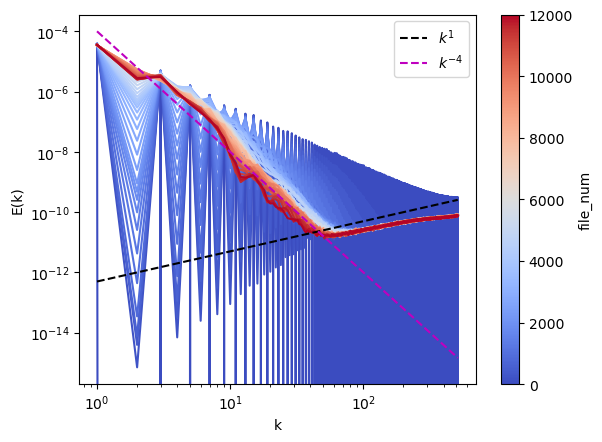

In [114]:
fig, ax = plt.subplots()
file_nums = sorted(spect_data['file_num'].unique())
# colors = cm.coolwarm(np.linspace(0, 1, len(file_nums)))
norm = mcolors.Normalize(vmin=min(file_nums), vmax=max(file_nums))
cmap = cm.coolwarm


# for color, (num, group) in zip(colors, spect_data.groupby('file_num')):
#     ax.plot(group[0], group[1], color=color, label=num)
idx = 0
for num, group in spect_data.groupby('file_num'):
    if idx > -1:
        ax.plot(group[0], group[1], color=cmap(norm(num)))
        k_vals = group[0]

    idx += 1
ax.set_xscale('log')
ax.set_yscale('log')

ax.plot(k_vals, 5e-13*k_vals, 'k--', label=r'$k^{1}$')
# ax.plot(k_vals, np.power(k_vals, -4), 'k--', label='y=x')
ax.plot(k_vals, 1e-4*np.power(k_vals.astype(float), -4), 'm--', label=r'$k^{-4}$')
ax.set_xlabel('k')
ax.set_ylabel('E(k)')
# ax.legend(title='file_num', loc='lower right')
ax.legend()
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=ax, label='file_num')
plt.show()

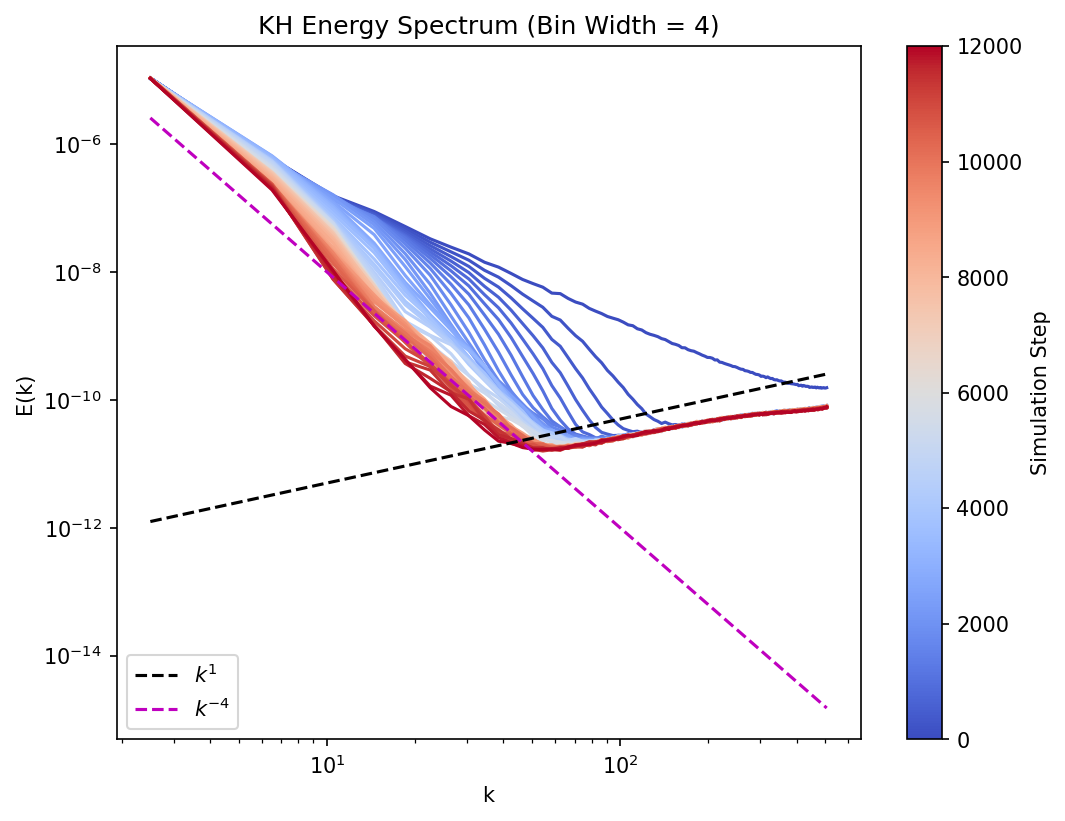

In [115]:

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
file_nums = sorted(spect_data['file_num'].unique())
norm = mcolors.Normalize(vmin=min(file_nums), vmax=max(file_nums))
cmap = cm.coolwarm

# Set your desired bin width (how many consecutive k-values to average together)
bin_width = 4

idx = 0
for num, group in spect_data.groupby('file_num'):
    if idx > -1:
        raw_k = group[0].values
        raw_E = group[1].values
        
        # Calculate how many full bins we can make
        num_bins = len(raw_k) // bin_width
        
        # Truncate the arrays so they divide perfectly by bin_width
        k_trunc = raw_k[:num_bins * bin_width]
        E_trunc = raw_E[:num_bins * bin_width]
        
        # Reshape into a 2D matrix and take the mean along the second axis
        # This instantly averages every chunk of 'bin_width' points!
        k_binned = k_trunc.reshape(-1, bin_width).mean(axis=1)
        E_binned = E_trunc.reshape(-1, bin_width).mean(axis=1)
        
        # Plot the smoothed data
        ax.plot(k_binned, E_binned, color=cmap(norm(num)))
        
        # Save for reference lines
        k_vals = k_binned

    idx += 1

ax.set_xscale('log')
ax.set_yscale('log')

ax.plot(k_vals, 5e-13 * k_vals, 'k--', label=r'$k^{1}$')
ax.plot(k_vals, 1e-4 * np.power(k_vals.astype(float), -4), 'm--', label=r'$k^{-4}$')

ax.set_xlabel('k')
ax.set_ylabel('E(k)')

# Legend for the reference lines
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[-2:], labels[-2:], loc='lower left')

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=ax, label='Simulation Step')

plt.title(f"KH Energy Spectrum (Bin Width = {bin_width})")
plt.show()

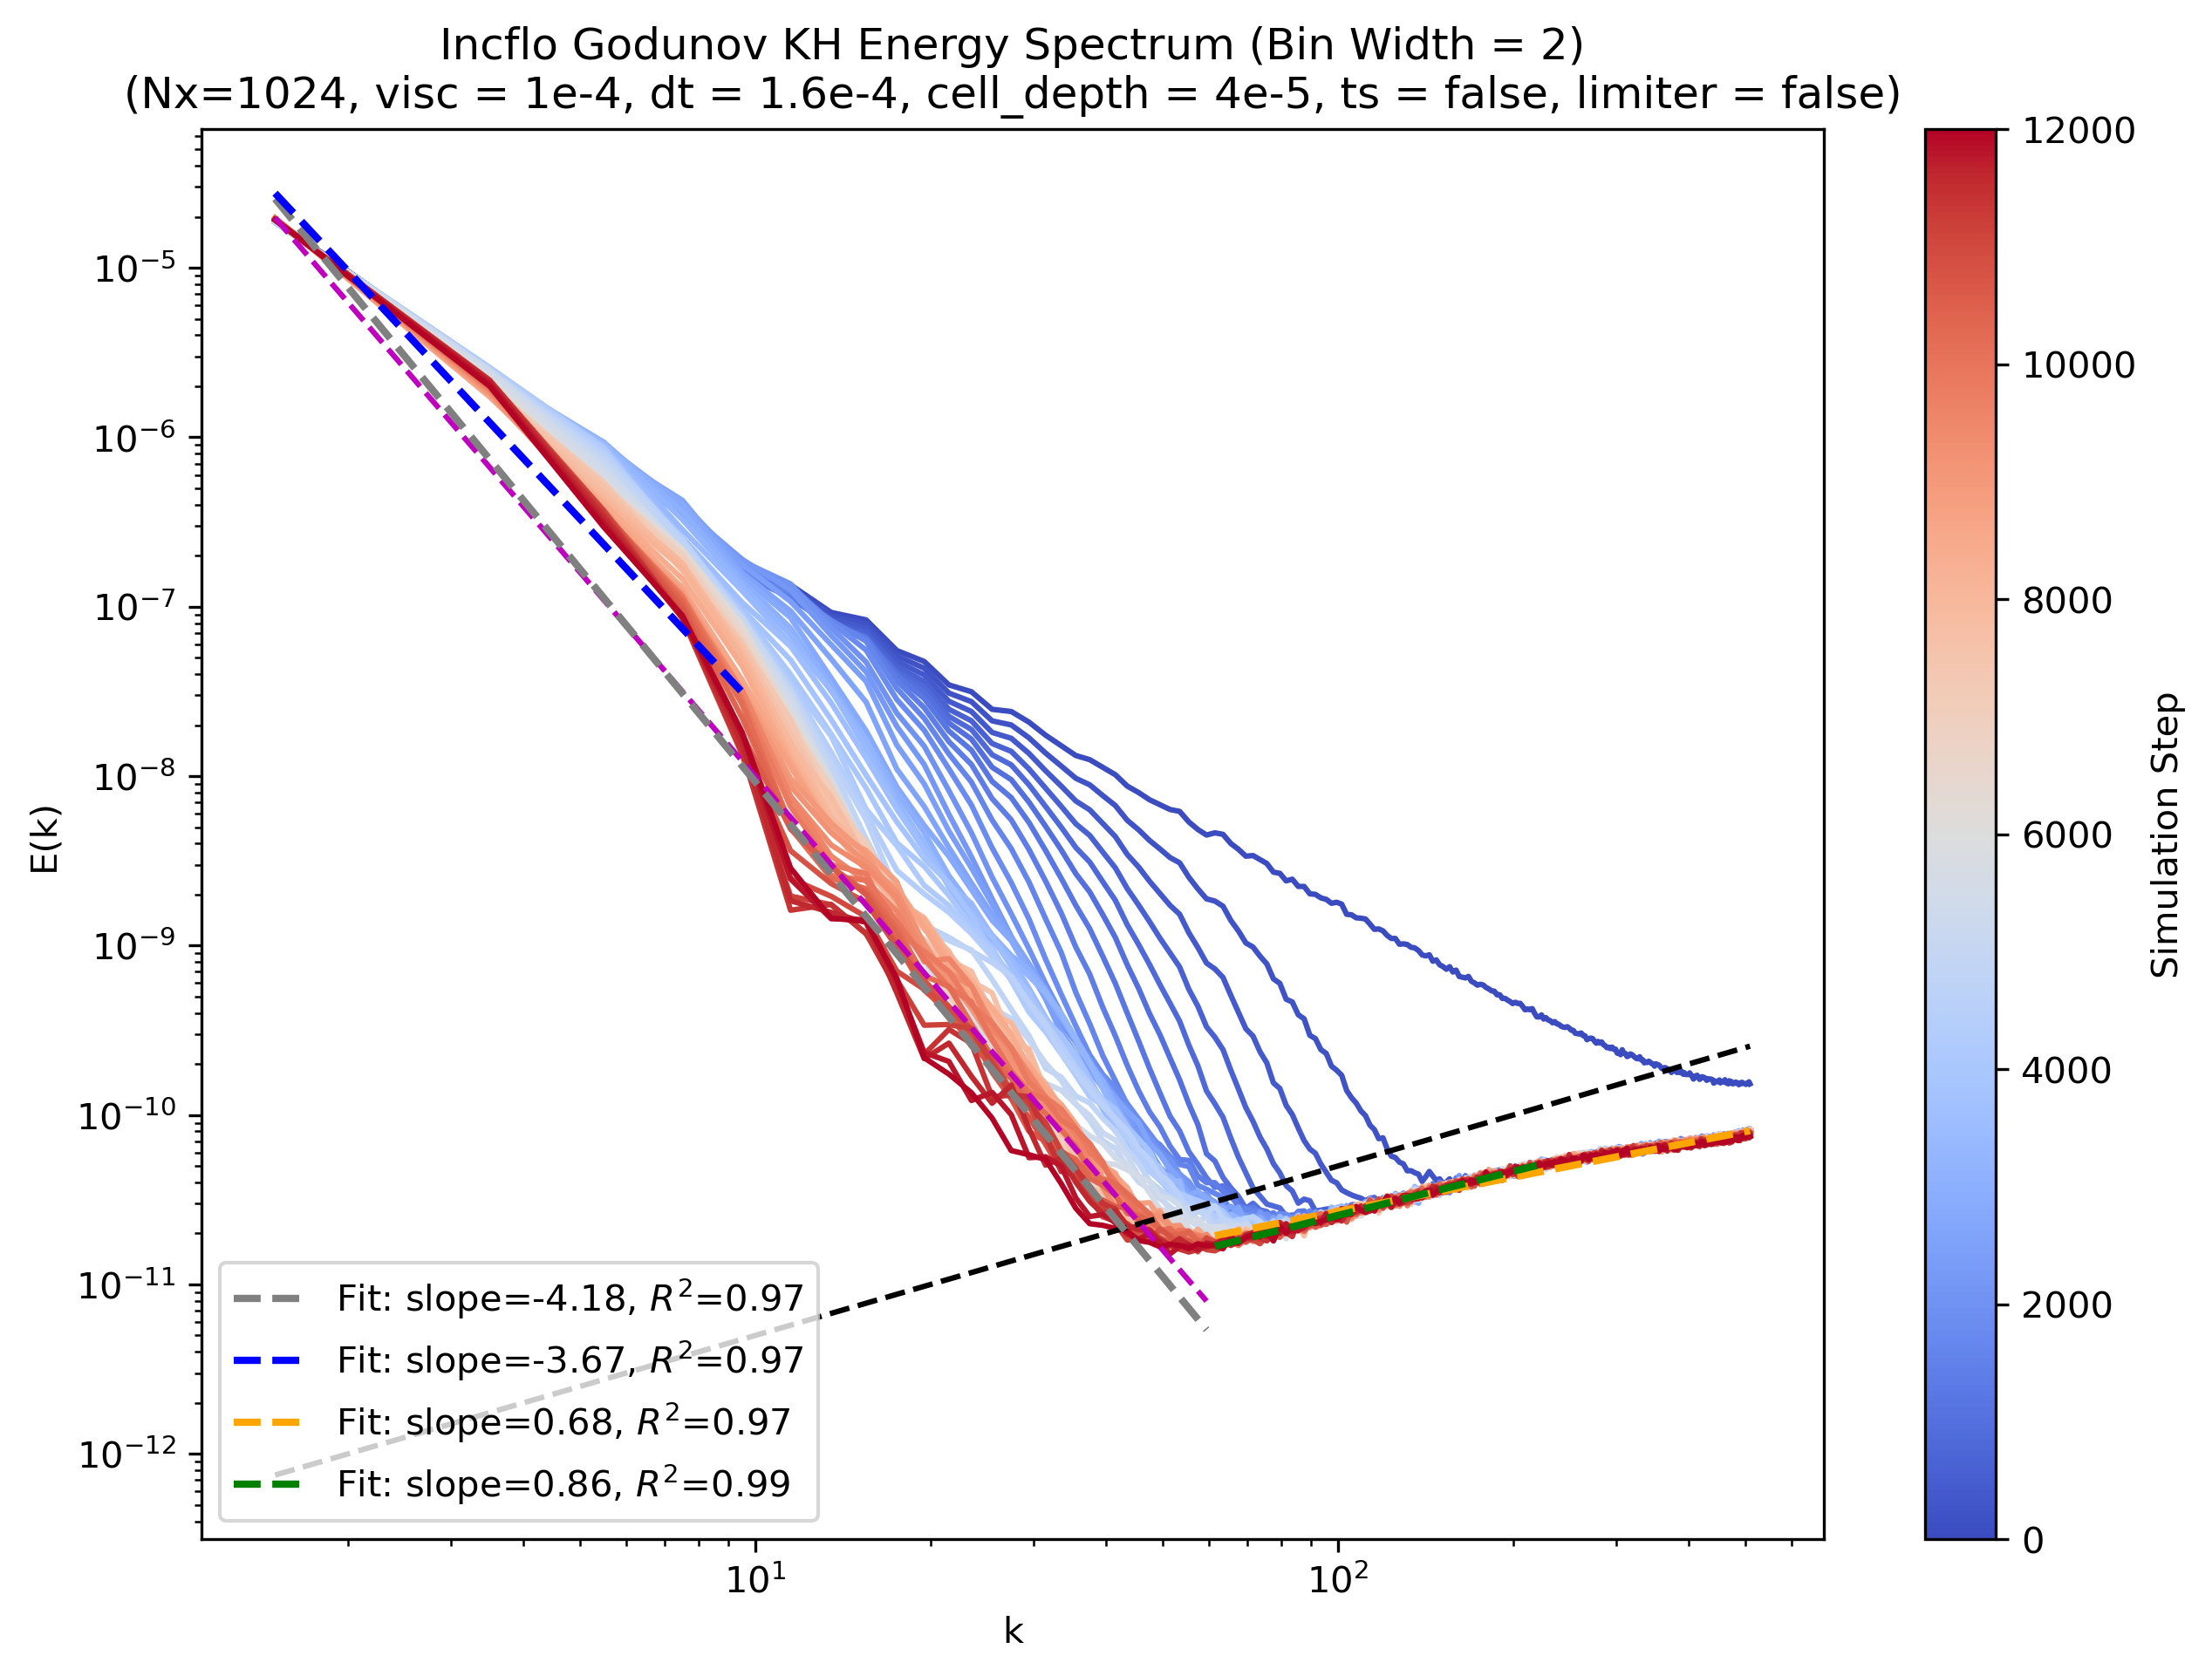

In [124]:
def add_power_law_fit(ax, k_vals, E_vals, k_min, k_max, color):
    """Fits E(k) = c * k^p, calculates R^2, and plots the fit."""
    mask = (k_vals >= k_min) & (k_vals <= k_max)
    k_fit, E_fit = k_vals[mask], E_vals[mask]
    
    if len(k_fit) < 2: return
    
    # Linear regression in log-log space
    log_k, log_E = np.log10(k_fit), np.log10(E_fit)
    slope, intercept, r_value, _, _ = linregress(log_k, log_E)
    r_squared = r_value**2
    
    # Plot the fit line
    fit_line = (10**intercept) * (k_fit**slope)
    label = f'Fit: slope={slope:.2f}, $R^2$={r_squared:.2f}'
    ax.plot(k_fit, fit_line, color=color, linestyle='--', linewidth=2, label=label)


fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
file_nums = sorted(spect_data['file_num'].unique())
norm = mcolors.Normalize(vmin=min(file_nums), vmax=max(file_nums))
cmap = cm.coolwarm

bin_width = 2
# target_time = 5000  # The specific timestep you want to fit

for num, group in spect_data.groupby('file_num'):
    raw_k, raw_E = group[0].values, group[1].values
    
    num_bins = len(raw_k) // bin_width
    k_binned = raw_k[:num_bins*bin_width].reshape(-1, bin_width).mean(axis=1)
    E_binned = raw_E[:num_bins*bin_width].reshape(-1, bin_width).mean(axis=1)
    
    ax.plot(k_binned, E_binned, color=cmap(norm(num)))
    
    # if num == target_time:
    fit_k, fit_E = k_binned, E_binned

ax.set_xscale('log')
ax.set_yscale('log')

# --- Add Reference Lines ---
ax.plot(fit_k, 5e-13 * fit_k, 'k--', label=r'Ref: $k^{1}$')
ax.plot(fit_k[:30], 1e-4 * np.power(fit_k[:30].astype(float), -4), 'm--', label=r'Ref: $k^{-4}$')

# --- Add Power Law Fits to the Target Timestep ---
add_power_law_fit(ax, fit_k, fit_E, k_min=1.0, k_max= 60.0, color='gray')
add_power_law_fit(ax, fit_k, fit_E, k_min=1.0, k_max=10.0, color='blue')
add_power_law_fit(ax, fit_k, fit_E, k_min=60.0, k_max=512.0, color='orange')
add_power_law_fit(ax, fit_k, fit_E, k_min=60.0, k_max=220.0, color='green')

ax.set_xlabel('k')
ax.set_ylabel('E(k)')

# Legend for the fits and reference lines
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[-4:], labels[-4:], loc='lower left')

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=ax, label='Simulation Step')

plt.title(f"Incflo Godunov KH Energy Spectrum (Bin Width = {bin_width})\n(Nx=1024, visc = 1e-4, dt = 1.6e-4, cell_depth = 4e-5, ts = false, limiter = false)")
plt.show()

In [107]:
k_binned

array([  2.5,   6.5,  10.5,  14.5,  18.5,  22.5,  26.5,  30.5,  34.5,
        38.5,  42.5,  46.5,  50.5,  54.5,  58.5,  62.5,  66.5,  70.5,
        74.5,  78.5,  82.5,  86.5,  90.5,  94.5,  98.5, 102.5, 106.5,
       110.5, 114.5, 118.5, 122.5, 126.5, 130.5, 134.5, 138.5, 142.5,
       146.5, 150.5, 154.5, 158.5, 162.5, 166.5, 170.5, 174.5, 178.5,
       182.5, 186.5, 190.5, 194.5, 198.5, 202.5, 206.5, 210.5, 214.5,
       218.5, 222.5, 226.5, 230.5, 234.5, 238.5, 242.5, 246.5, 250.5,
       254.5, 258.5, 262.5, 266.5, 270.5, 274.5, 278.5, 282.5, 286.5,
       290.5, 294.5, 298.5, 302.5, 306.5, 310.5, 314.5, 318.5, 322.5,
       326.5, 330.5, 334.5, 338.5, 342.5, 346.5, 350.5, 354.5, 358.5,
       362.5, 366.5, 370.5, 374.5, 378.5, 382.5, 386.5, 390.5, 394.5,
       398.5, 402.5, 406.5, 410.5, 414.5, 418.5, 422.5, 426.5, 430.5,
       434.5, 438.5, 442.5, 446.5, 450.5, 454.5, 458.5, 462.5, 466.5,
       470.5, 474.5, 478.5, 482.5, 486.5, 490.5, 494.5, 498.5, 502.5,
       506.5])

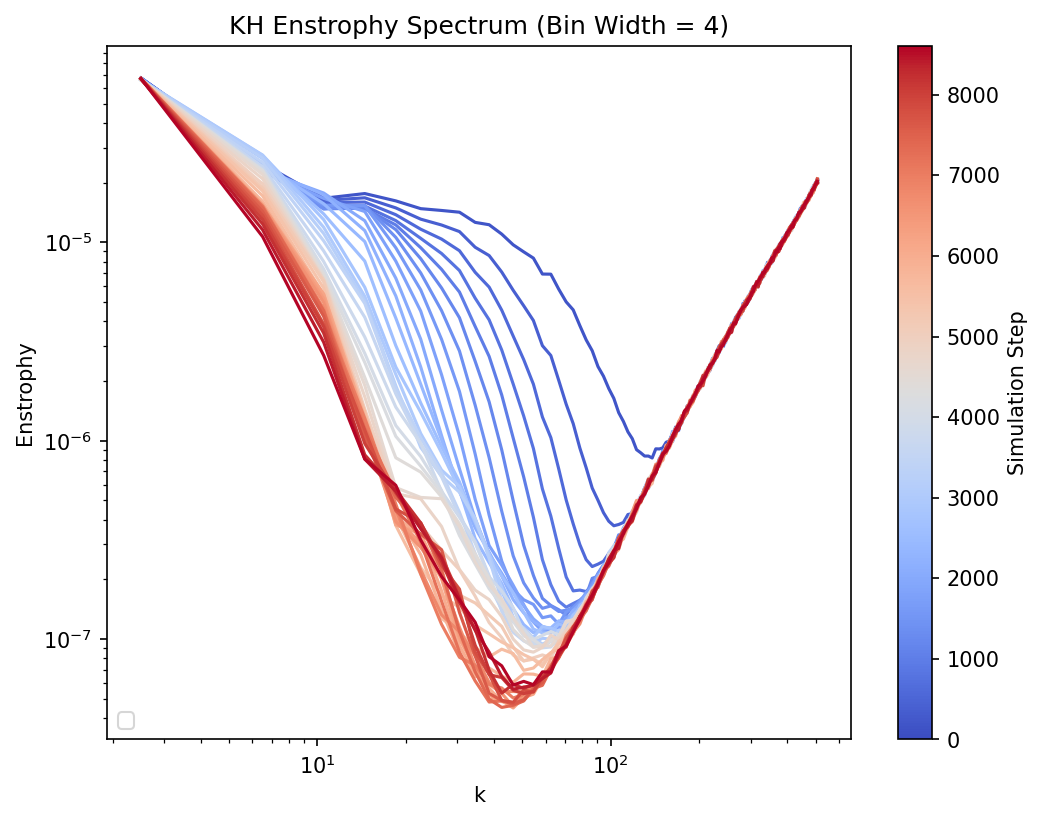

In [108]:

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
file_nums = sorted(spect_data['file_num'].unique())
norm = mcolors.Normalize(vmin=min(file_nums), vmax=max(file_nums))
cmap = cm.coolwarm

# Set your desired bin width (how many consecutive k-values to average together)
bin_width = 4

idx = 0
for num, group in spect_data.groupby('file_num'):
    if idx > 0:
        raw_k = group[0].values
        raw_E = group[1].values
        
        # Calculate how many full bins we can make
        num_bins = len(raw_k) // bin_width
        
        # Truncate the arrays so they divide perfectly by bin_width
        k_trunc = raw_k[:num_bins * bin_width]
        E_trunc = raw_E[:num_bins * bin_width]
        
        # Reshape into a 2D matrix and take the mean along the second axis
        # This instantly averages every chunk of 'bin_width' points!
        k_binned = k_trunc.reshape(-1, bin_width).mean(axis=1)
        E_binned = E_trunc.reshape(-1, bin_width).mean(axis=1)
        
        # Plot the smoothed data
        ax.plot(k_binned, E_binned*np.power(k_binned, 2), color=cmap(norm(num)))

    idx += 1

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('k')
ax.set_ylabel('Enstrophy')

# Legend for the reference lines
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[-2:], labels[-2:], loc='lower left')

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=ax, label='Simulation Step')

plt.title(f"KH Enstrophy Spectrum (Bin Width = {bin_width})")
plt.show()

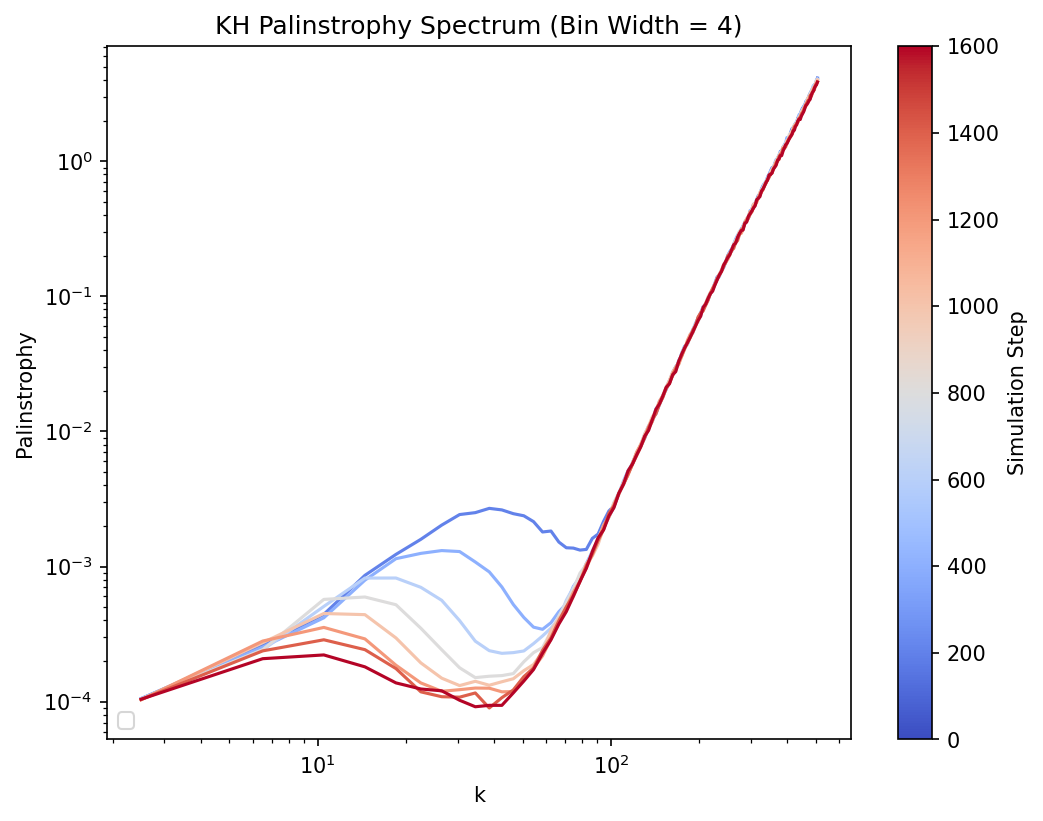

In [47]:

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
file_nums = sorted(spect_data['file_num'].unique())
norm = mcolors.Normalize(vmin=min(file_nums), vmax=max(file_nums))
cmap = cm.coolwarm

# Set your desired bin width (how many consecutive k-values to average together)
bin_width = 4

idx = 0
for num, group in spect_data.groupby('file_num'):
    if idx > 0:
        raw_k = group[0].values
        raw_E = group[1].values
        
        # Calculate how many full bins we can make
        num_bins = len(raw_k) // bin_width
        
        # Truncate the arrays so they divide perfectly by bin_width
        k_trunc = raw_k[:num_bins * bin_width]
        E_trunc = raw_E[:num_bins * bin_width]
        
        # Reshape into a 2D matrix and take the mean along the second axis
        # This instantly averages every chunk of 'bin_width' points!
        k_binned = k_trunc.reshape(-1, bin_width).mean(axis=1)
        E_binned = E_trunc.reshape(-1, bin_width).mean(axis=1)
        
        # Plot the smoothed data
        ax.plot(k_binned, E_binned*np.power(k_binned, 4), color=cmap(norm(num)))

    idx += 1

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('k')
ax.set_ylabel('Palinstrophy')

# Legend for the reference lines
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[-2:], labels[-2:], loc='lower left')

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=ax, label='Simulation Step')

plt.title(f"KH Palinstrophy Spectrum (Bin Width = {bin_width})")
plt.show()